<a href="https://colab.research.google.com/github/AnnabelleMcSharry/AI-ML-Car-Data/blob/main/salesForcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

sales = pd.read_csv("sales training set.csv")

In [21]:
print("Missing values:\n", sales.isnull().sum())

# Check for duplicates
print("Duplicates:\n", sales.duplicated().sum())

# Count total number of rows
print("Total number of rows:", sales.shape[0])

Missing values:
 ProductID               0
Weight               1463
FatContent              0
ProductVisibility       0
ProductType             0
MRP                     0
OutletID                0
EstablishmentYear       0
OutletSize           2410
LocationType            0
OutletType              0
OutletSales             0
dtype: int64
Duplicates:
 0
Total number of rows: 8523


In [22]:
#analysis to see how much data would be lost if i just dropped all of the line swith missing values

new_sales = sales.dropna()

print("Total records that would be lost if deleted:")
print(sales.shape[0] - new_sales.shape[0])

#45% too high to just drop all values so will ahve to do further analysis
print("Percentage of records lost:")
print(((sales.shape[0] - new_sales.shape[0]) / sales.shape[0]) * 100)


Total records that would be lost if deleted:
3873
Percentage of records lost:
45.44174586413235


In [23]:
#counts how many times each outlet size appears including howmany times a missing value appears

print(sales["OutletSize"].value_counts(dropna=False))

#shows the percentage of each time the different outlet size occurs
#28% is too much to delete
print(sales["OutletSize"].value_counts(normalize=True, dropna=False) * 100)


OutletSize
Medium    2793
NaN       2410
Small     2388
High       932
Name: count, dtype: int64
OutletSize
Medium    32.770151
NaN       28.276428
Small     28.018303
High      10.935117
Name: proportion, dtype: float64


In [24]:
#checking to see if outlet size is linked to outlet type to see if i can fill in the values mnaually
print(pd.crosstab(sales["OutletType"], sales["OutletSize"], dropna=False))

#shows how many outlet types have missing values- all missiing values are in grocery store or supermarket type 1
#50% of super market type 1 is small
#grocery stores are all small if they ahve a value
print(pd.crosstab(sales["OutletType"], sales["OutletSize"].isnull()))



OutletSize         High  Medium  Small   NaN
OutletType                                  
Grocery Store         0       0    528   555
Supermarket Type1   932     930   1860  1855
Supermarket Type2     0     928      0     0
Supermarket Type3     0     935      0     0
OutletSize         False  True 
OutletType                     
Grocery Store        528    555
Supermarket Type1   3722   1855
Supermarket Type2    928      0
Supermarket Type3    935      0


In [25]:
#all known grocery stores are small so i will change them all to small
sales.loc[
    (sales["OutletType"] == "Grocery Store") & (sales["OutletSize"].isnull()),"OutletSize"] = "Small"

In [26]:
#because there is almost exact 25-25-50 split for supermarlet type 1 between high-medium-small i used this distribution to fill the missing values
import numpy as np

# Select missing Outlet_Size rows where Outlet_Type is Supermarket Type1
missing_type1 = ((sales["OutletType"] == "Supermarket Type1") &(sales["OutletSize"].isnull()))

# Calculate the existing size distribution for known Supermarket Type1 rows
type1_distribution = sales.loc[(sales["OutletType"] == "Supermarket Type1") &(sales["OutletSize"].notnull()),"OutletSize"].value_counts(normalize=True)

print(type1_distribution)

# Fill missing values using the same distribution
np.random.seed(42)

sales.loc[missing_type1, "OutletSize"] = np.random.choice(type1_distribution.index,size=missing_type1.sum(),p=type1_distribution.values)


OutletSize
Small     0.499731
High      0.250403
Medium    0.249866
Name: proportion, dtype: float64


In [27]:
print("Missing values:\n", sales.isnull().sum())

# Check for duplicates
print("Duplicates:\n", sales.duplicated().sum())

# Count total number of rows
print("Total number of rows:", sales.shape[0])


Missing values:
 ProductID               0
Weight               1463
FatContent              0
ProductVisibility       0
ProductType             0
MRP                     0
OutletID                0
EstablishmentYear       0
OutletSize              0
LocationType            0
OutletType              0
OutletSales             0
dtype: int64
Duplicates:
 0
Total number of rows: 8523


count    7060.000000
mean       12.857645
std         4.643456
min         4.555000
25%         8.773750
50%        12.600000
75%        16.850000
max        21.350000
Name: Weight, dtype: float64
Percentage of missing weights:
17.165317376510618


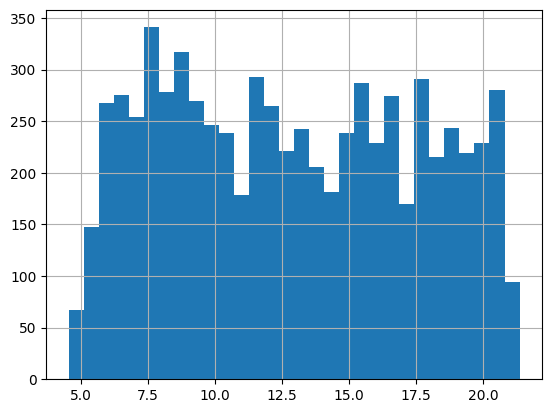

In [28]:
#looking at the distributions of the weight so i can try to figure out how to best deal with the missing data

print(sales["Weight"].describe())

sales["Weight"].hist(bins=30)

print("Percentage of missing weights:")
print((sales["Weight"].isnull().sum() / len(sales)) * 100)

#17% is missing a weight which is too high to delete

In [29]:
# Check whether missing Weight values can be filled using the same item sold in other stores

total_missing_weight_rows = sales["Weight"].isnull().sum()

unique_items_with_missing_weight = sales.loc[ sales["Weight"].isnull(), "ProductID"].nunique()

# Count how many known weight values each item has
known_weights_per_item = sales.groupby("ProductID")["Weight"].nunique()


items_with_known_weight = (known_weights_per_item > 0).sum()
items_with_no_known_weight = (known_weights_per_item == 0).sum()

print("Number of rows that do not have a weight", total_missing_weight_rows)
print("The number of unique items without a weight", unique_items_with_missing_weight)
print("Number of items with known weights in other stores", items_with_known_weight)
print("Number of items with no weight in the whole database", items_with_no_known_weight)



Number of rows that do not have a weight 1463
The number of unique items without a weight 1142
Number of items with known weights in other stores 1555
Number of items with no weight in the whole database 4


In [30]:
# Fill missing Weight values using the same item's known weight
sales["Weight"] = sales.groupby("ProductID")["Weight"].transform(lambda x: x.fillna(x.mean()))

# Check how many missing values are left
print("Missing Weight values remaining:")
print(sales["Weight"].isnull().sum())


Missing Weight values remaining:
4


In [31]:
#droppning the remaining items without a weight as i will only lose 20 records
sales = sales.dropna(subset=["Weight"])





In [32]:
#getting rid of the identifiers beacsue they are not factors that will help with regression they are descriptive

sales = sales.drop(columns=["ProductID", "OutletID"])
print(sales.head())
print(sales.columns)


   Weight FatContent  ProductVisibility            ProductType       MRP  \
0    9.30    Low Fat           0.016047                  Dairy  249.8092   
1    5.92    Regular           0.019278            Soft Drinks   48.2692   
2   17.50    Low Fat           0.016760                   Meat  141.6180   
3   19.20    Regular           0.000000  Fruits and Vegetables  182.0950   
4    8.93    Low Fat           0.000000              Household   53.8614   

   EstablishmentYear OutletSize LocationType         OutletType  OutletSales  
0               1999     Medium       Tier 1  Supermarket Type1    3735.1380  
1               2009     Medium       Tier 3  Supermarket Type2     443.4228  
2               1999     Medium       Tier 1  Supermarket Type1    2097.2700  
3               1998      Small       Tier 3      Grocery Store     732.3800  
4               1987       High       Tier 3  Supermarket Type1     994.7052  
Index(['Weight', 'FatContent', 'ProductVisibility', 'ProductType', 'M

In [33]:
#finding unique values before i encode
categorical_columns = ["FatContent", "ProductType", "OutletSize", "LocationType","OutletType"]

for col in categorical_columns:
    print(f"\nUnique values in {col}:")
    print(sales[col].unique())



Unique values in FatContent:
['Low Fat' 'Regular' 'low fat' 'LF' 'reg']

Unique values in ProductType:
['Dairy' 'Soft Drinks' 'Meat' 'Fruits and Vegetables' 'Household'
 'Baking Goods' 'Snack Foods' 'Frozen Foods' 'Breakfast'
 'Health and Hygiene' 'Hard Drinks' 'Canned' 'Breads' 'Starchy Foods'
 'Others' 'Seafood']

Unique values in OutletSize:
['Medium' 'Small' 'High']

Unique values in LocationType:
['Tier 1' 'Tier 3' 'Tier 2']

Unique values in OutletType:
['Supermarket Type1' 'Supermarket Type2' 'Grocery Store'
 'Supermarket Type3']


In [34]:
#merging the fat content column as the labels all just mean regular or low fat
sales["FatContent"] = sales["FatContent"].replace({"LF": "Low Fat","low fat": "Low Fat","reg": "Regular" })

print(sales["FatContent"].unique())
print(sales["FatContent"].value_counts())


['Low Fat' 'Regular']
FatContent
Low Fat    5516
Regular    3003
Name: count, dtype: int64


In [35]:
#encoding fat content
sales = pd.get_dummies( sales, columns=["FatContent"], drop_first=True,  dtype=int)
print(sales.head())
print(sales.columns)

   Weight  ProductVisibility            ProductType       MRP  \
0    9.30           0.016047                  Dairy  249.8092   
1    5.92           0.019278            Soft Drinks   48.2692   
2   17.50           0.016760                   Meat  141.6180   
3   19.20           0.000000  Fruits and Vegetables  182.0950   
4    8.93           0.000000              Household   53.8614   

   EstablishmentYear OutletSize LocationType         OutletType  OutletSales  \
0               1999     Medium       Tier 1  Supermarket Type1    3735.1380   
1               2009     Medium       Tier 3  Supermarket Type2     443.4228   
2               1999     Medium       Tier 1  Supermarket Type1    2097.2700   
3               1998      Small       Tier 3      Grocery Store     732.3800   
4               1987       High       Tier 3  Supermarket Type1     994.7052   

   FatContent_Regular  
0                   0  
1                   1  
2                   0  
3                   1  
4       

remeber what the type of encoding you use for when there is high cardinality and use it on item type
ordinal encoding on outlet size and location type
one hot encoding for outlet type

In [36]:
#used one hot encoding for item type as there is only 16 categories
sales = pd.get_dummies(sales, columns=["ProductType"], drop_first=True, dtype=int)

print(sales.head())
print(sales.columns)


   Weight  ProductVisibility       MRP  EstablishmentYear OutletSize  \
0    9.30           0.016047  249.8092               1999     Medium   
1    5.92           0.019278   48.2692               2009     Medium   
2   17.50           0.016760  141.6180               1999     Medium   
3   19.20           0.000000  182.0950               1998      Small   
4    8.93           0.000000   53.8614               1987       High   

  LocationType         OutletType  OutletSales  FatContent_Regular  \
0       Tier 1  Supermarket Type1    3735.1380                   0   
1       Tier 3  Supermarket Type2     443.4228                   1   
2       Tier 1  Supermarket Type1    2097.2700                   0   
3       Tier 3      Grocery Store     732.3800                   1   
4       Tier 3  Supermarket Type1     994.7052                   0   

   ProductType_Breads  ...  ProductType_Fruits and Vegetables  \
0                   0  ...                                  0   
1               

In [37]:
outlet_size_order = {"Small": 0, "Medium": 1, "High": 2}

sales["OutletSize"] = sales["OutletSize"].map(outlet_size_order)

print(sales.head())
print(sales.columns)


   Weight  ProductVisibility       MRP  EstablishmentYear  OutletSize  \
0    9.30           0.016047  249.8092               1999           1   
1    5.92           0.019278   48.2692               2009           1   
2   17.50           0.016760  141.6180               1999           1   
3   19.20           0.000000  182.0950               1998           0   
4    8.93           0.000000   53.8614               1987           2   

  LocationType         OutletType  OutletSales  FatContent_Regular  \
0       Tier 1  Supermarket Type1    3735.1380                   0   
1       Tier 3  Supermarket Type2     443.4228                   1   
2       Tier 1  Supermarket Type1    2097.2700                   0   
3       Tier 3      Grocery Store     732.3800                   1   
4       Tier 3  Supermarket Type1     994.7052                   0   

   ProductType_Breads  ...  ProductType_Fruits and Vegetables  \
0                   0  ...                                  0   
1         

In [38]:
location_type_order = {"Tier 1": 0, "Tier 2": 1, "Tier 3": 2}
sales["LocationType"] = sales["LocationType"].map(location_type_order)
print(sales.head())
print(sales.columns)


   Weight  ProductVisibility       MRP  EstablishmentYear  OutletSize  \
0    9.30           0.016047  249.8092               1999           1   
1    5.92           0.019278   48.2692               2009           1   
2   17.50           0.016760  141.6180               1999           1   
3   19.20           0.000000  182.0950               1998           0   
4    8.93           0.000000   53.8614               1987           2   

   LocationType         OutletType  OutletSales  FatContent_Regular  \
0             0  Supermarket Type1    3735.1380                   0   
1             2  Supermarket Type2     443.4228                   1   
2             0  Supermarket Type1    2097.2700                   0   
3             2      Grocery Store     732.3800                   1   
4             2  Supermarket Type1     994.7052                   0   

   ProductType_Breads  ...  ProductType_Fruits and Vegetables  \
0                   0  ...                                  0   
1   

In [39]:
sales = pd.get_dummies(sales, columns=["OutletType"], drop_first=True, dtype=int)

print(sales.head())
print(sales.columns)


   Weight  ProductVisibility       MRP  EstablishmentYear  OutletSize  \
0    9.30           0.016047  249.8092               1999           1   
1    5.92           0.019278   48.2692               2009           1   
2   17.50           0.016760  141.6180               1999           1   
3   19.20           0.000000  182.0950               1998           0   
4    8.93           0.000000   53.8614               1987           2   

   LocationType  OutletSales  FatContent_Regular  ProductType_Breads  \
0             0    3735.1380                   0                   0   
1             2     443.4228                   1                   0   
2             0    2097.2700                   0                   0   
3             2     732.3800                   1                   0   
4             2     994.7052                   0                   0   

   ProductType_Breakfast  ...  ProductType_Household  ProductType_Meat  \
0                      0  ...                      0  